<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Variation: Single star evolution</p>
    <o style='font-size:20px;'>How does removing binary interactions after BHs?</p>
</div>

In [2]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.interpolate import interp1d
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Load data

In [3]:
files = ["fiducial", "singles"]
labels = ["Binaries", "Singles"]
colours = ["#333", "#96B73B"]

pops, data = helpers.load_postprocessed_pops(files, labels, colours)
binaries, singles = pops

# Totals

Singles
  Total: 6673504, NSs: 4923066, BHs: 1750438
Binaries
  Total: 6944059, NSs: 5017575, BHs: 1926484


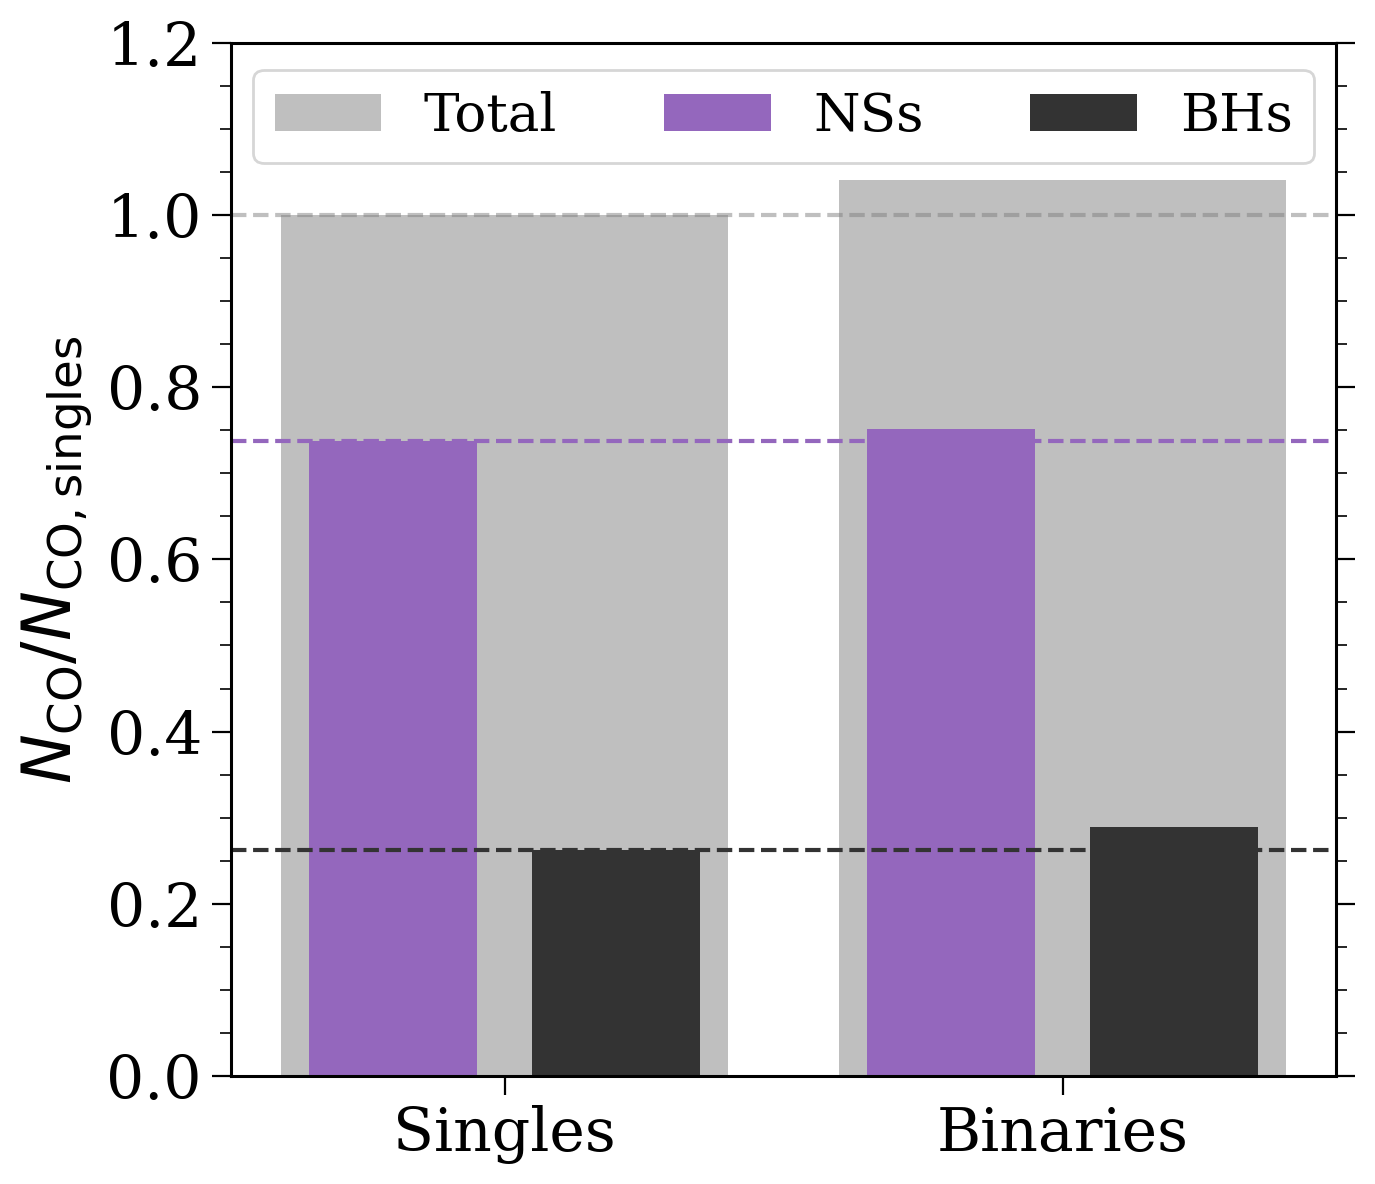

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

total_single_cos = None

for i, pop in enumerate([singles, binaries]):
    n_ns = len(data[pop.label]["mass"]["NS"])
    n_bh = len(data[pop.label]["mass"]["BH"])
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")

    if total_single_cos is None and pop.label == "Singles":
        total_single_cos = n_ns + n_bh

    ax.bar(i, (n_ns + n_bh) / total_single_cos, label="Total" if i == 0 else None, color="grey", alpha=0.5)
    ax.bar(i - 0.2, n_ns / total_single_cos, width=0.3, label="NSs" if i == 0 else None, color="tab:purple")
    ax.bar(i + 0.2, n_bh / total_single_cos, width=0.3, label="BHs" if i == 0 else None, color="#333")

    if i == 0:
        ax.axhline((n_ns + n_bh) / total_single_cos, color="grey", alpha=0.5, ls='--')
        ax.axhline(n_ns / total_single_cos, color="tab:purple", ls='--')
        ax.axhline(n_bh / total_single_cos, color="#333", ls='--')

pops = [singles, binaries]
ax.set_xticks(range(len(pops)), [pop.label for pop in pops])
ax.set_ylabel(r"$N_{\rm CO} / N_{\rm CO, singles}$")
ax.legend(ncol=3, loc='upper center', fontsize=0.8*fs)

ax.set(
    ylim=(0, 1.2),
)

ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# show yticks on both sides
ax.yaxis.set_ticks_position('both')

plt.tight_layout()
plt.show()

## Takeaways

Binaries are produce slightly more compact objects?

- Mergers increasing the amount that can reach core-collapse?

Binaries don't have a strong effect on the NSs, but slightly increase the BH total.

- Hypothesis: Stars can now become NSs, some NSs can now become BHs, BHs only go up


# Mass distributions

In [4]:
f'{data["Binaries"]["mass"]["BH"].sum() / data["Singles"]["mass"]["BH"].sum():1.1f}x more mass in BHs in binaries vs singles'

'1.2x more mass in BHs in binaries vs singles'

In [5]:
f'{data["Binaries"]["mass"]["BH"].mean() / data["Singles"]["mass"]["BH"].mean():1.1f}x higher average mass in binaries vs singles'

'1.1x higher average mass in binaries vs singles'

# Kinematics

## Scale heights

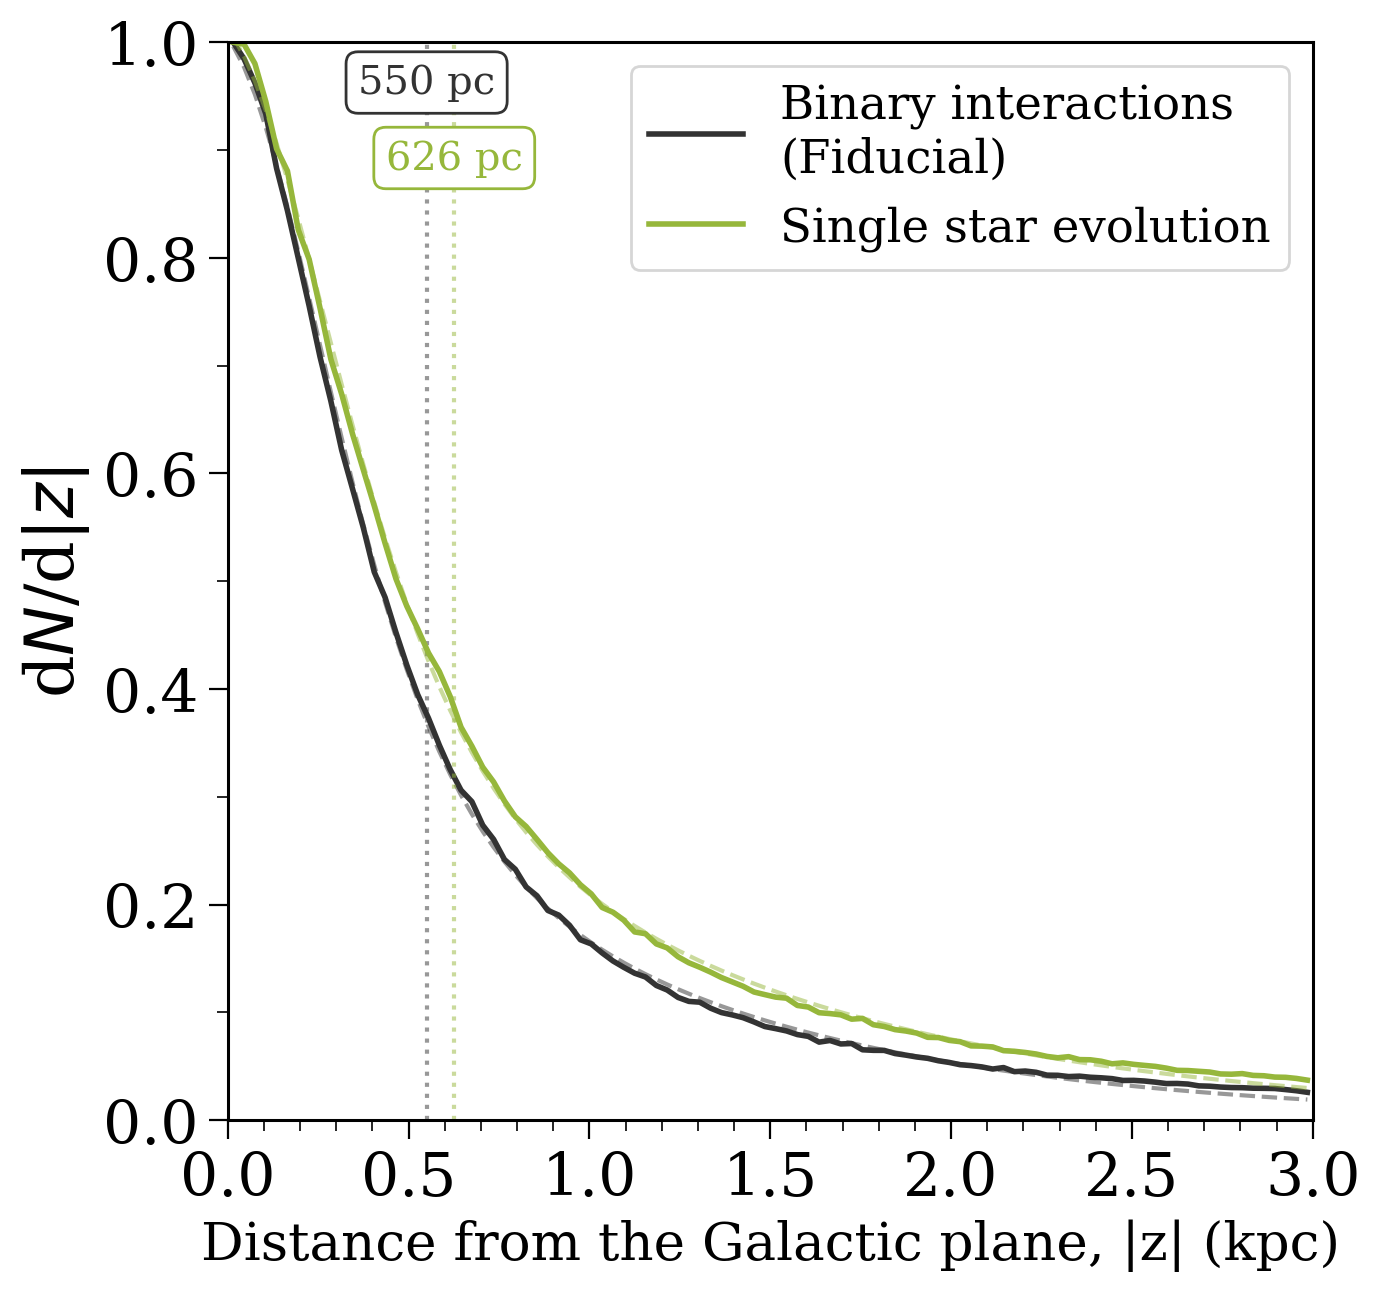

In [9]:
reload(plotting)

fig, ax = plt.subplots(figsize=(7, 7))

for z, label, colour, loc in zip(
    [data["Binaries"]["pos"]["BH"][:, 2][~data["Binaries"]["escaped"]["BH"]],
     data["Singles"]["pos"]["BH"][:, 2][~data["Singles"]["escaped"]["BH"]]],
    ["Binary interactions\n(Fiducial)", "Single star evolution"],
    ["#333", singles.colour],
    [0.98, 0.98 - 0.07]
):
    scale_height, scale_height_err, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 101),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc
    )

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_singles.pdf", format="pdf", bbox_inches="tight")

plt.show()

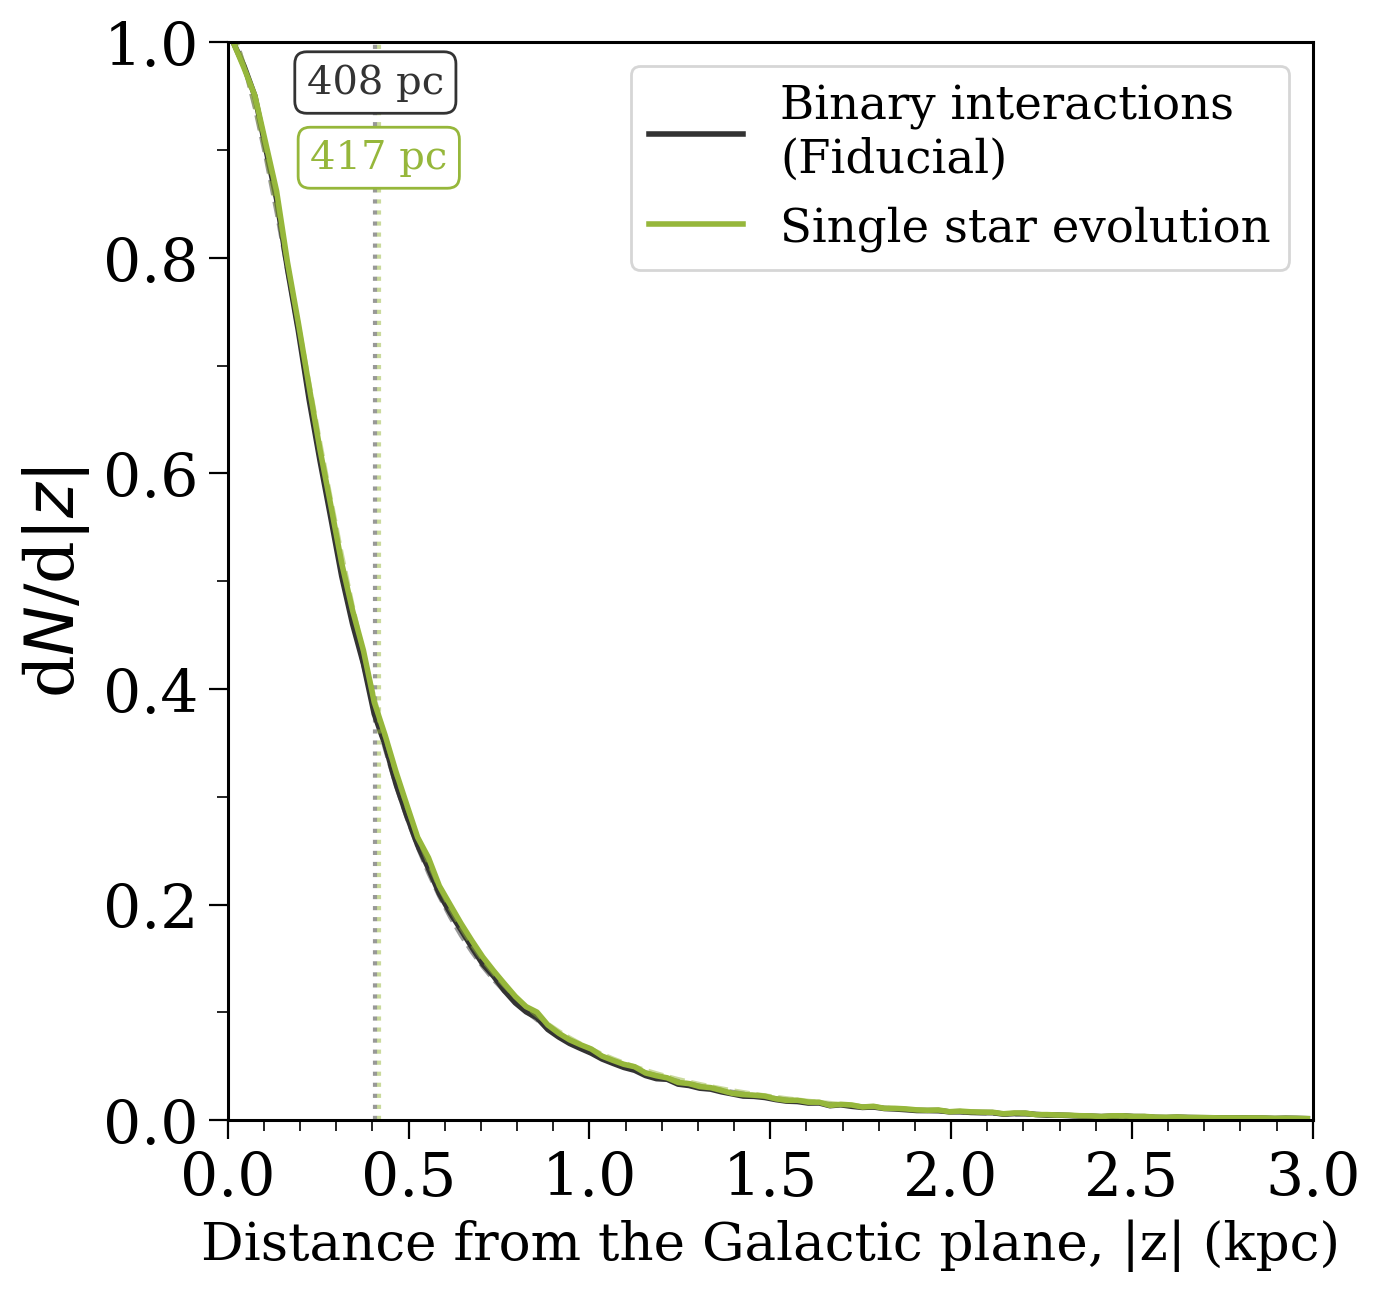

In [43]:
reload(plotting)

fig, ax = plt.subplots(figsize=(7, 7))

for z, label, colour, loc in zip(
    [data["Binaries"]["init_z"]["BH"][~data["Binaries"]["escaped"]["BH"]],
     data["Singles"]["init_z"]["BH"][~data["Singles"]["escaped"]["BH"]]],
    ["Binary interactions\n(Fiducial)", "Single star evolution"],
    ["#333", singles.colour],
    [0.98, 0.98 - 0.07]
):
    scale_height, scale_height_err, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 101),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc
    )

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_singles.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Vertical position histograms

Singles 0.36334317338071304
Binaries 0.4842453936785224
Singles 0.26869719705006456
Binaries 0.3871683315331462


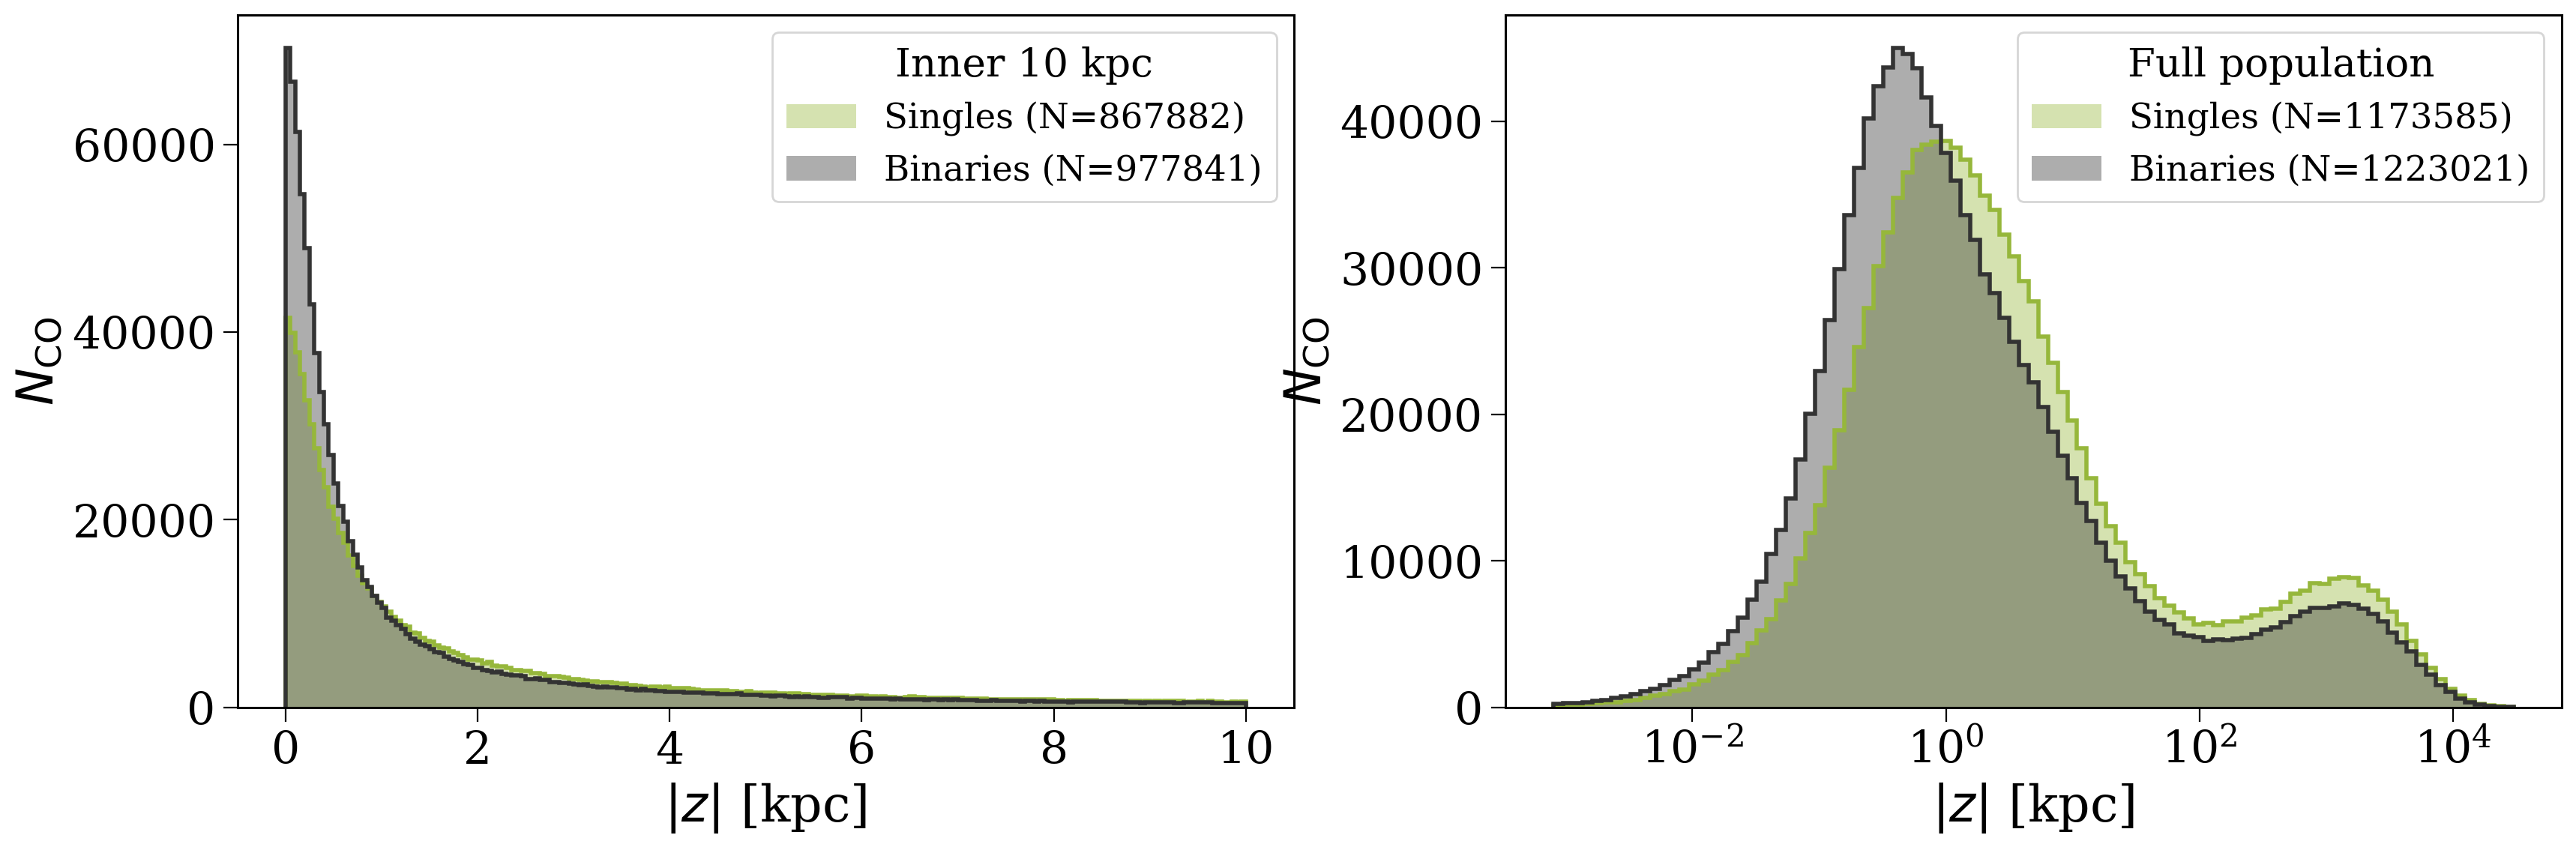

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 10, 201), np.geomspace(8e-4, 3e4, 100)]
labels = ['Inner 10 kpc', 'Full population']

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    for pop in [singles, binaries]:
        co_pos = data[pop.label]["pos"]["CO"]

        mask = np.abs(co_pos[:, 2]) < bins[-1]

        print(pop.label, (abs(co_pos[:, 2]) < 0.5).sum() / mask.sum())

        ax.hist(np.abs(co_pos[:, 2]), bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(np.abs(co_pos[:, 2]), bins=bins, alpha=0.4, color=pop.colour,
                label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

## Density distributions

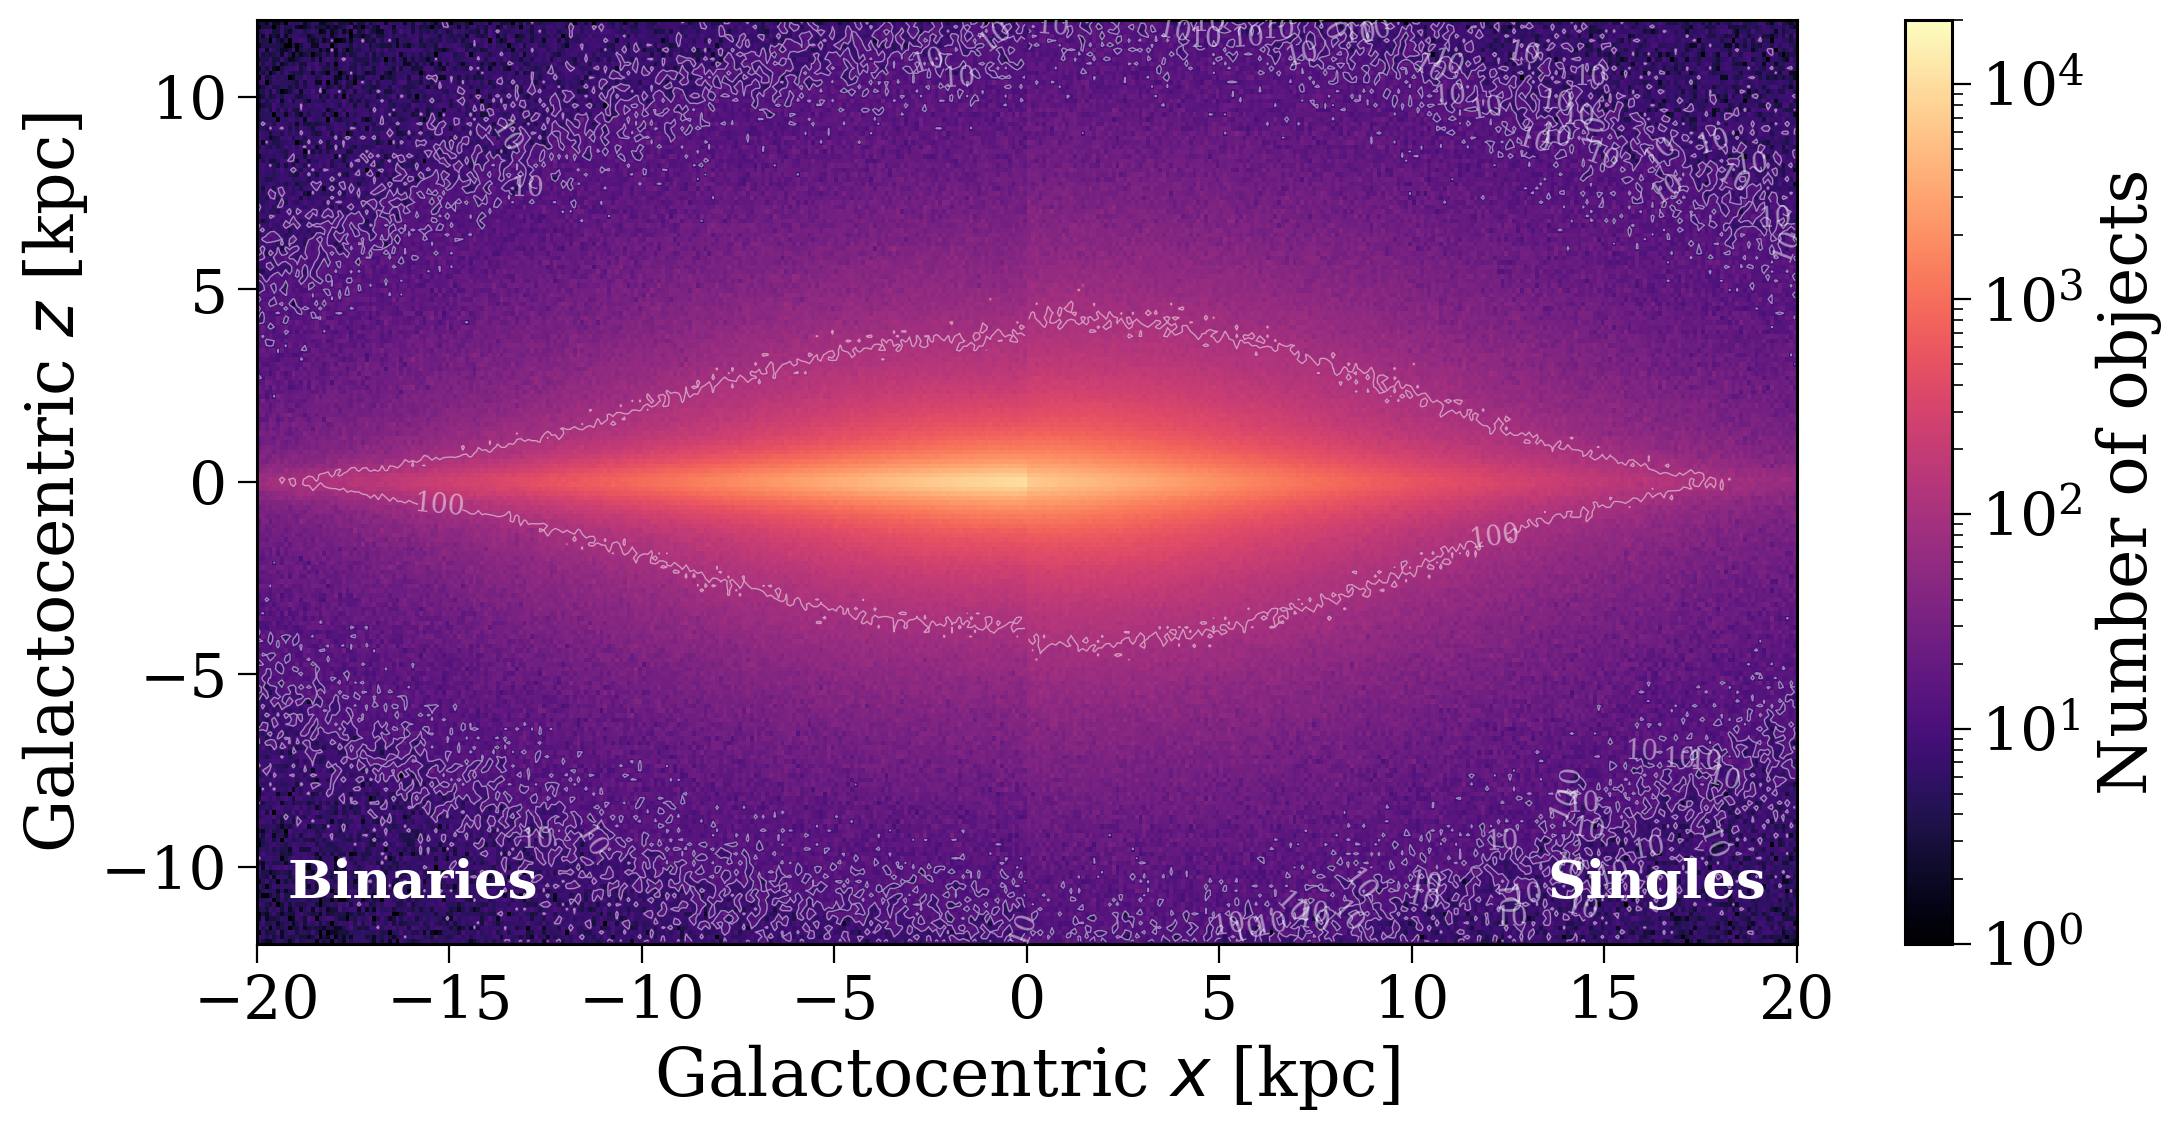

(<Figure size 1400x600 with 2 Axes>,
 <Axes: xlabel='Galactocentric $x$ [kpc]', ylabel='Galactocentric $z$ [kpc]'>)

In [10]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[data["Singles"]["pos"]["CO"][:, 0], data["Binaries"]["pos"]["CO"][:, 0]],
    zs=[data["Singles"]["pos"]["CO"][:, 2], data["Binaries"]["pos"]["CO"][:, 2]],
    labels=["Binaries", "Singles"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=0.25,
    contours=[10, 100],
    apply_smoothing=True,
)

# BELOW HERE REQUIRES FULL DATA

## It's mergers right?

Mergers can both increase and decrease the total number of COs formed from a given total stellar mass since:

1. A merger of two stars that could both have become COs decreases your CO count by 1
2. A merger of two low mass stars that couldn't become COs without merging increases your count by 1

Arguably from the IMF, the latter should be more common and so binaries should make many more COs

In [ ]:
# takes about 5 minutes to run
binaries = helpers.load_distributed_pop(
    base_path='/mnt/ceph/users/twagg/underworld/',
    sim_name="fiducial",
    parts=34,
    label="Fiducial",
    colour="#333"
)

Loading distributed population Fiducial from 34 parts
   loaded part 1/34 of Fiducial with 181264 binaries
   loaded part 2/34 of Fiducial with 181884 binaries
   loaded part 3/34 of Fiducial with 181795 binaries
   loaded part 4/34 of Fiducial with 183160 binaries
   loaded part 5/34 of Fiducial with 182296 binaries
   loaded part 6/34 of Fiducial with 181831 binaries
   loaded part 7/34 of Fiducial with 181735 binaries
   loaded part 8/34 of Fiducial with 181843 binaries
   loaded part 9/34 of Fiducial with 181815 binaries
   loaded part 10/34 of Fiducial with 181543 binaries
   loaded part 11/34 of Fiducial with 181895 binaries
   loaded part 12/34 of Fiducial with 181063 binaries
   loaded part 13/34 of Fiducial with 182335 binaries
   loaded part 14/34 of Fiducial with 182008 binaries
   loaded part 15/34 of Fiducial with 182334 binaries
   loaded part 16/34 of Fiducial with 181560 binaries
   loaded part 17/34 of Fiducial with 181810 binaries
   loaded part 18/34 of Fiducial with

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(


In [8]:
stellar_merger_nums = binaries.bpp[(
    (
        (binaries.bpp['kstar_1'] == 15) & (binaries.bpp["kstar_2"] < 13)
    ) | (
        (binaries.bpp['kstar_2'] == 15) & (binaries.bpp["kstar_1"] < 13)
    )
)].drop_duplicates(subset="bin_num", keep="first")["bin_num"]

In [9]:
merger_inits = binaries.initC.loc[stellar_merger_nums]

In [10]:
bh_bin_nums = binaries.final_bpp["bin_num"][(binaries.final_bpp["kstar_1"] == 14) | (binaries.final_bpp["kstar_2"] == 14)].values

In [11]:
merger_bhs = binaries.final_bpp.loc[merger_inits["bin_num"]][["kstar_1", "kstar_2"]].min(axis=1) == 14

In [12]:
min_bh_mass_df = pd.read_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass")
min_bh_mass = interp1d(min_bh_mass_df["metallicity"], min_bh_mass_df["mass_1"])

In [22]:
LIM = 7.5
high_mass_mergers = (merger_inits["mass_1"] >= LIM) & (merger_inits["mass_2"] >= LIM)
low_mass_mergers = (merger_inits["mass_1"] < LIM) & (merger_inits["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits)}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_inits):.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_inits):.2%})")

Total mergers: 4667490
  High mass mergers: 1363908 (29.22%)
  Low mass mergers: 1710718 (36.65%)


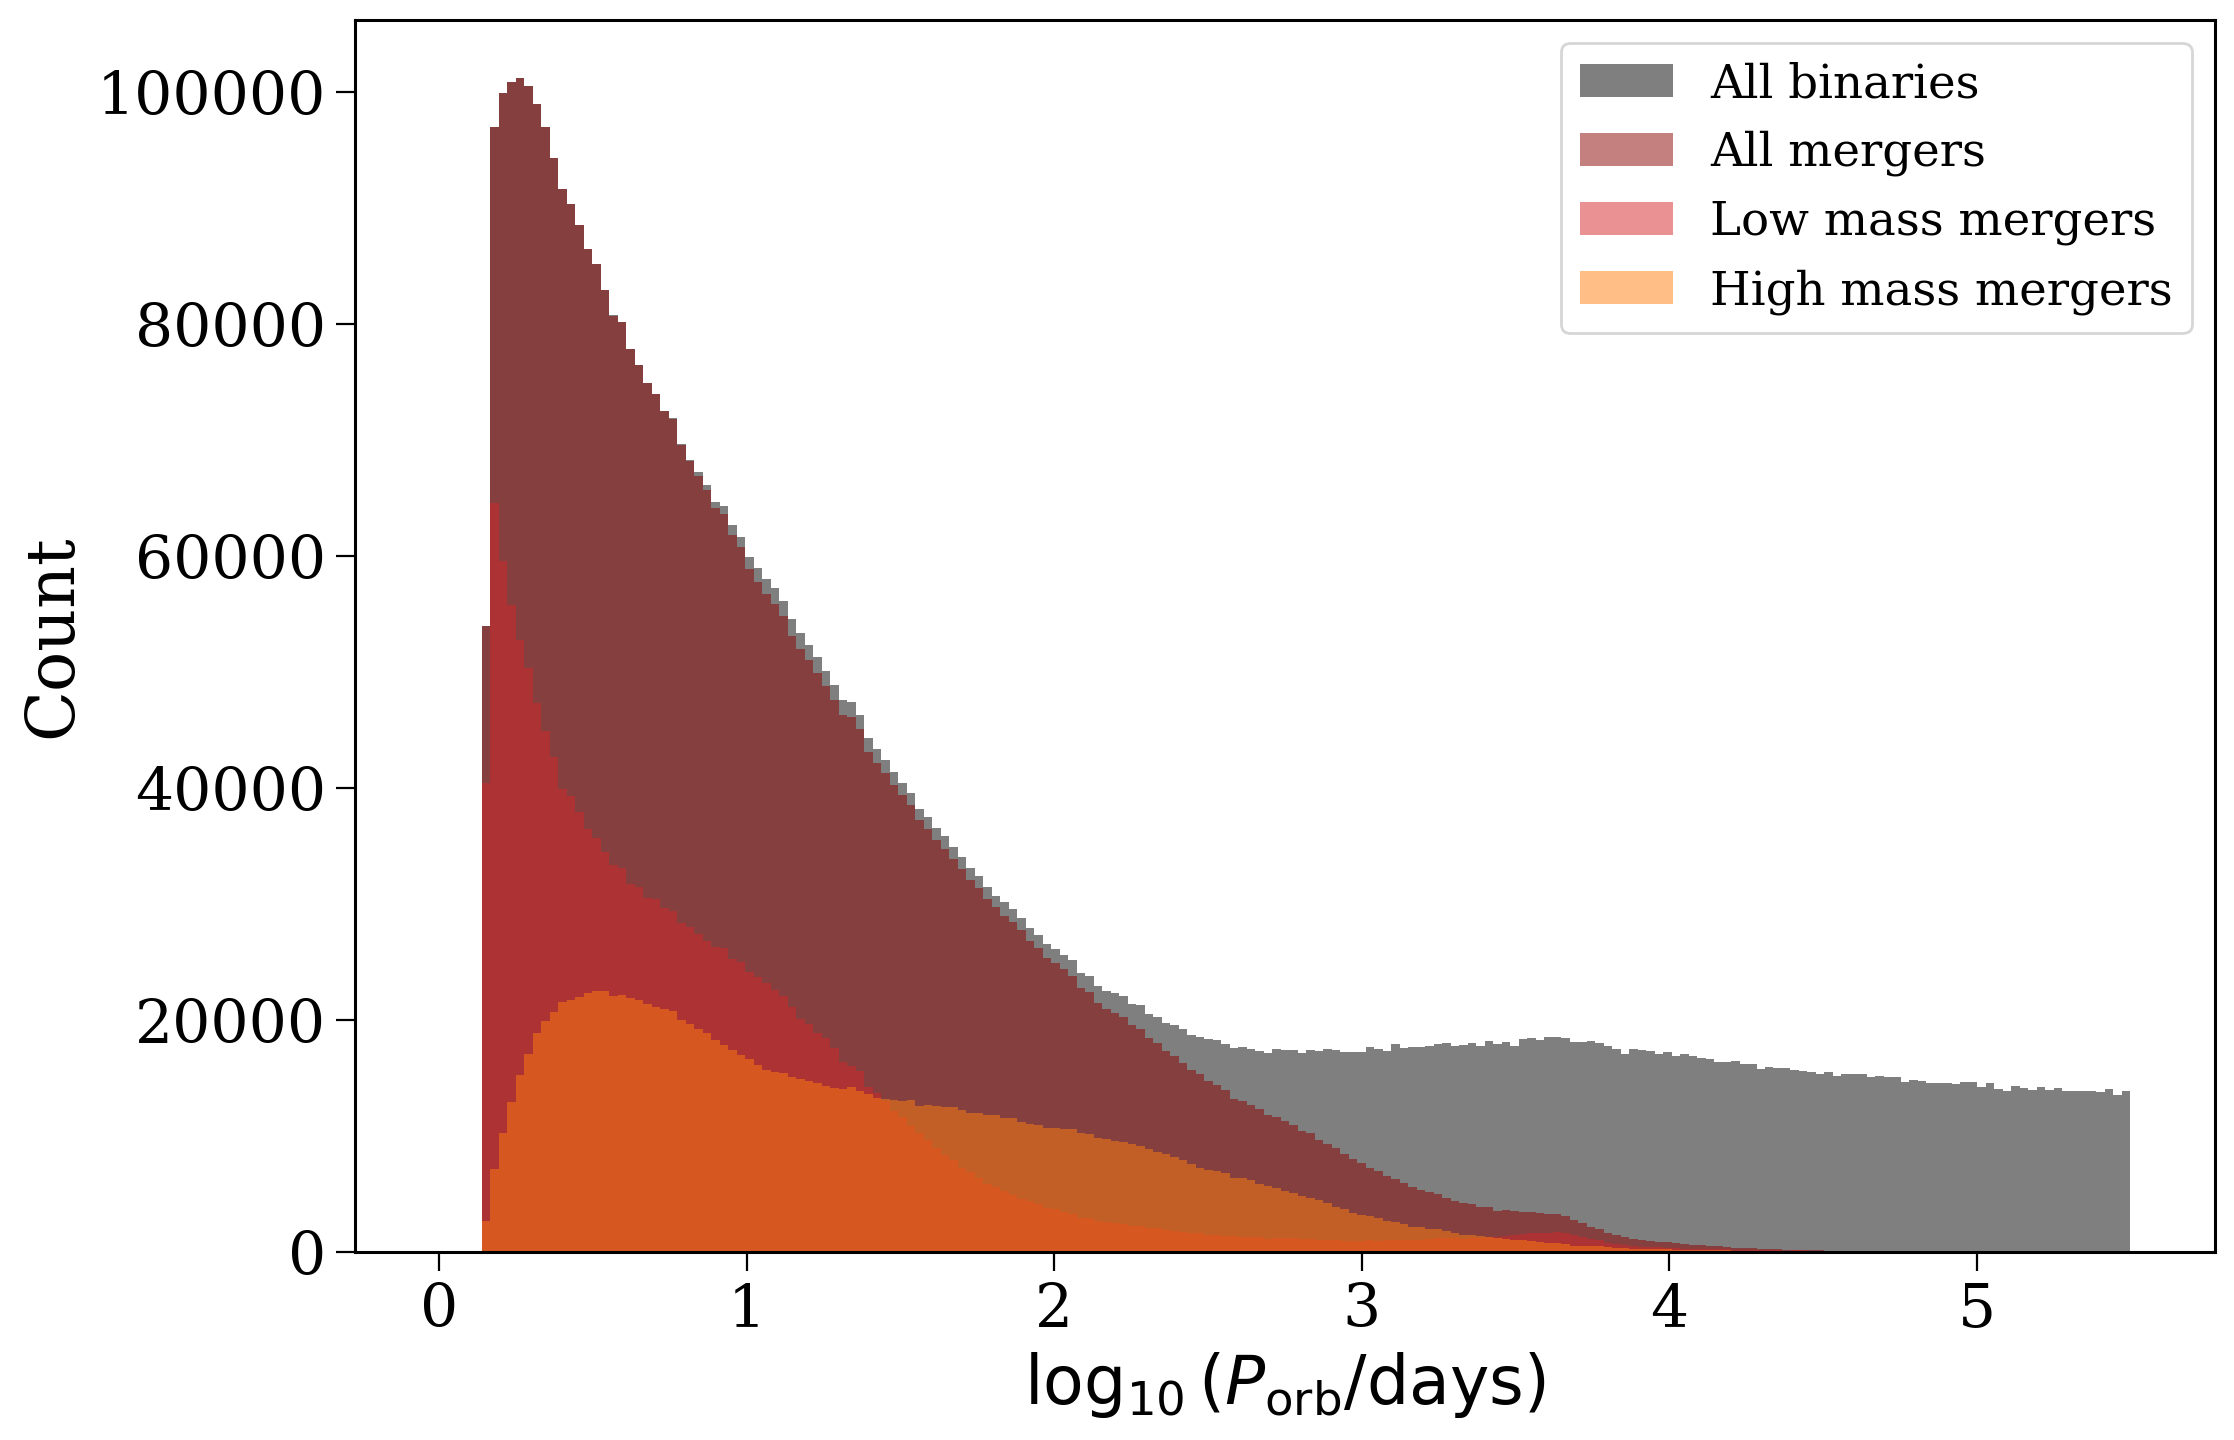

In [23]:
fig, ax = plt.subplots()

ax.hist(np.log10(binaries.initC["porb"]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="All binaries", color="black")
ax.hist(np.log10(merger_inits["porb"]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="All mergers", color="darkred")
ax.hist(np.log10(merger_inits["porb"][low_mass_mergers]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="Low mass mergers", color="tab:red")
ax.hist(np.log10(merger_inits["porb"][high_mass_mergers]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="High mass mergers", color="tab:orange")

ax.set(
    xlabel=r"$\log_{10}(P_{\rm orb} / \mathrm{days})$",
    ylabel="Count",
)
ax.legend()
plt.show()

In [24]:
LIM = min_bh_mass(merger_inits[merger_bhs]["metallicity"].values)
high_mass_mergers = (merger_inits[merger_bhs]["mass_1"] >= LIM) & (merger_inits[merger_bhs]["mass_2"] >= LIM)
low_mass_mergers = (merger_inits[merger_bhs]["mass_1"] < LIM) & (merger_inits[merger_bhs]["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits[merger_bhs])}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / data['Binaries']['n_BH']:.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / data['Binaries']['n_BH']:.2%})")

Total mergers: 1230852
  High mass mergers: 314834 (16.34%)
  Low mass mergers: 473663 (24.59%)


## Full fallback occurrences

In [33]:
# takes about 5 minutes to run
singles = helpers.load_distributed_pop(
    base_path='/mnt/ceph/users/twagg/underworld/',
    sim_name="singles",
    parts=34,
    label="Singles",
    colour=colours[1]
)

Loading distributed population Singles from 34 parts
   loaded part 1/34 of Singles with 133528 binaries
   loaded part 2/34 of Singles with 134002 binaries
   loaded part 3/34 of Singles with 133844 binaries
   loaded part 4/34 of Singles with 134463 binaries
   loaded part 5/34 of Singles with 134184 binaries
   loaded part 6/34 of Singles with 133638 binaries
   loaded part 7/34 of Singles with 133840 binaries
   loaded part 8/34 of Singles with 134033 binaries
   loaded part 9/34 of Singles with 133782 binaries
   loaded part 10/34 of Singles with 134023 binaries
   loaded part 11/34 of Singles with 134134 binaries
   loaded part 12/34 of Singles with 133510 binaries
   loaded part 13/34 of Singles with 134365 binaries
   loaded part 14/34 of Singles with 133647 binaries
   loaded part 15/34 of Singles with 134245 binaries
   loaded part 16/34 of Singles with 133348 binaries
   loaded part 17/34 of Singles with 134367 binaries
   loaded part 18/34 of Singles with 133581 binaries
  

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(


In [38]:
binary_kicks = binaries.kick_info[binaries.kick_info["star"] != 0.0].loc[data["Binaries"]["bin_nums"]["BH"]]
(binary_kicks["natal_kick"] == 0.0).sum() / len(binary_kicks) * 100, np.mean(binary_kicks["natal_kick"]), np.mean(binary_kicks["natal_kick"])

(np.float64(14.34488888819214),
 np.float64(147.6714318525889),
 np.float64(147.6714318525889))

In [39]:
single_kicks = singles.kick_info[singles.kick_info["star"] != 0.0].loc[data["Singles"]["bin_nums"]["BH"]]
(single_kicks["natal_kick"] == 0.0).sum() / len(single_kicks) * 100, np.mean(single_kicks["natal_kick"]), np.median(single_kicks["natal_kick"])

(np.float64(11.048365724180494),
 np.float64(163.35321978372443),
 np.float64(110.64303446143425))

# Initial conditions

## Mass

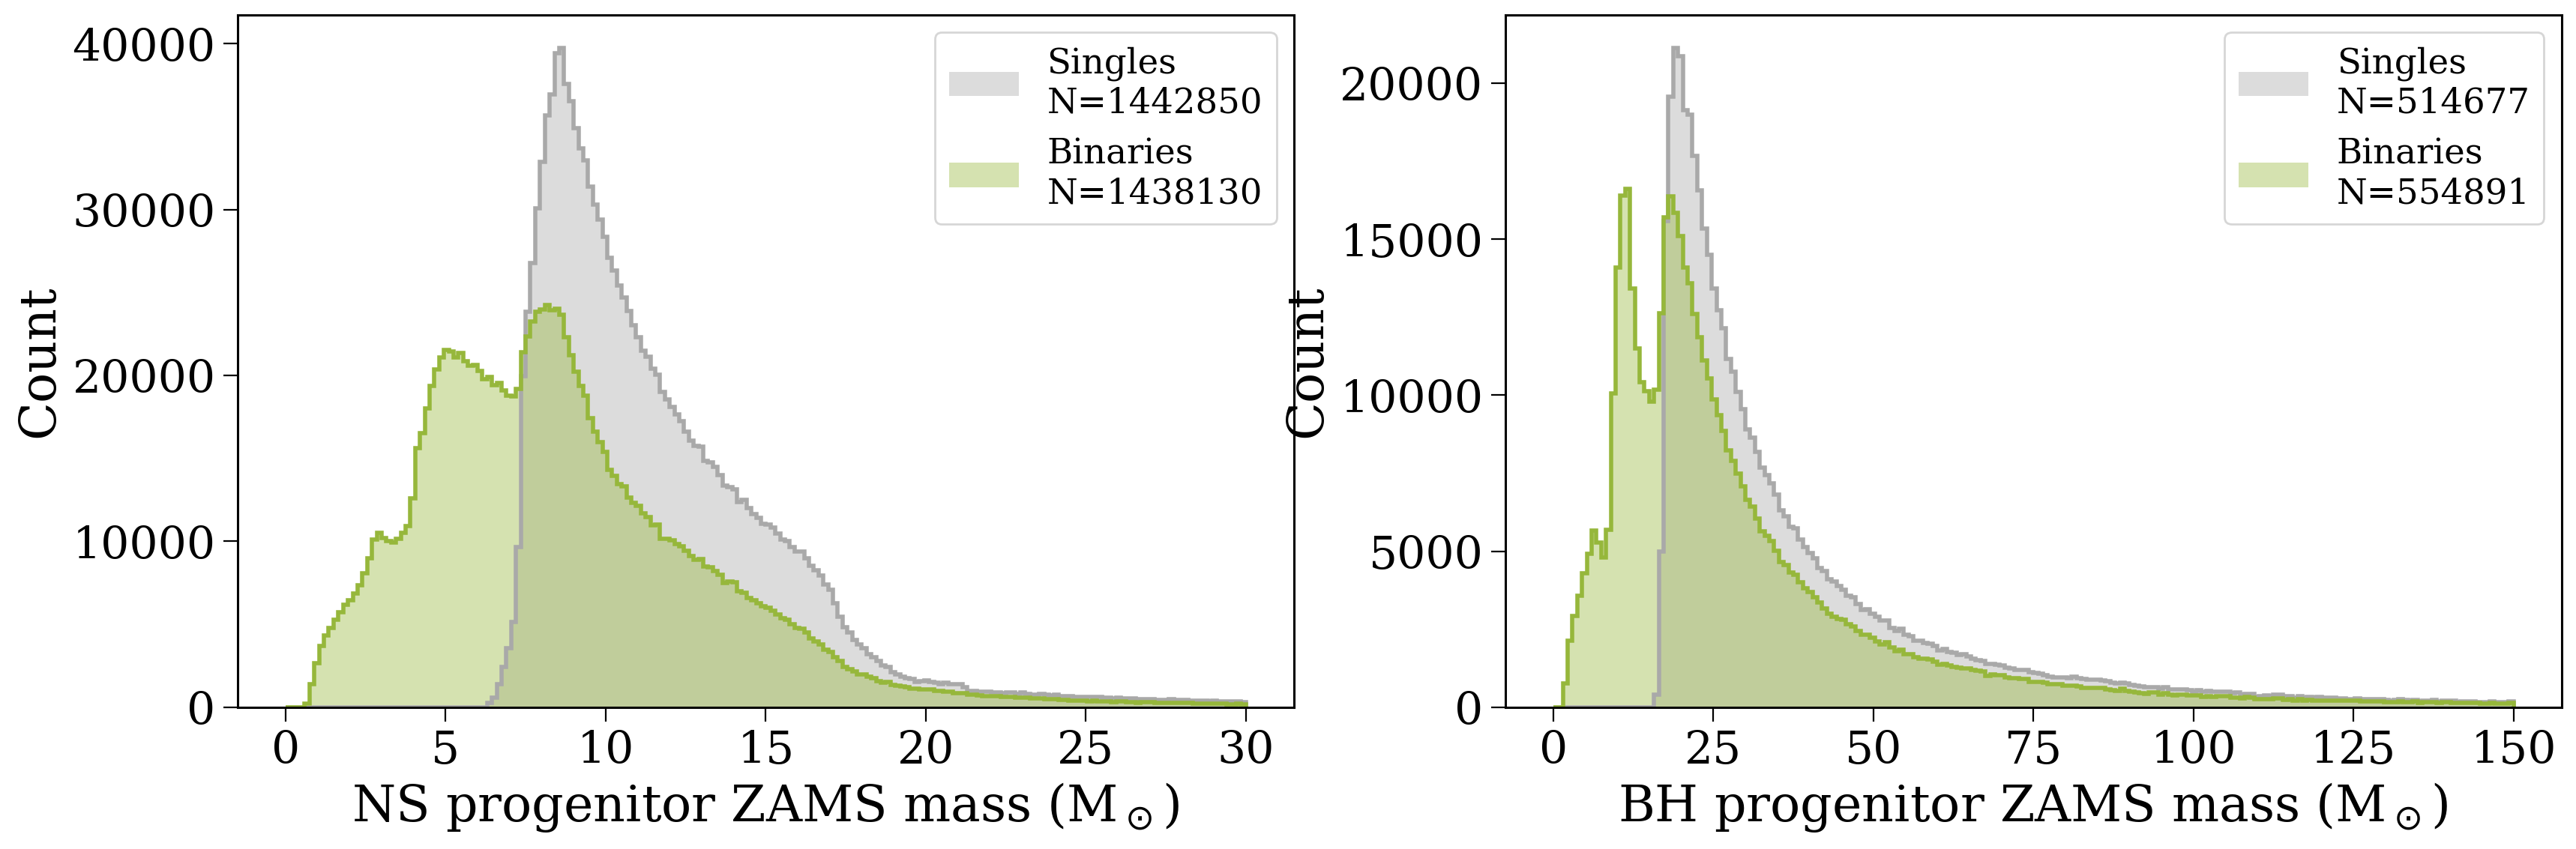

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    plotting.compare_table_quantity(
        pops=[singles, binaries],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor ZAMS mass (M$_\odot$)",
        ylabel="Count",
        density=False,
        ax=ax,
        fig=fig,
        show=False
    )
plt.show()

## Metallicity

Worrying spike up at $Z = 0.03$

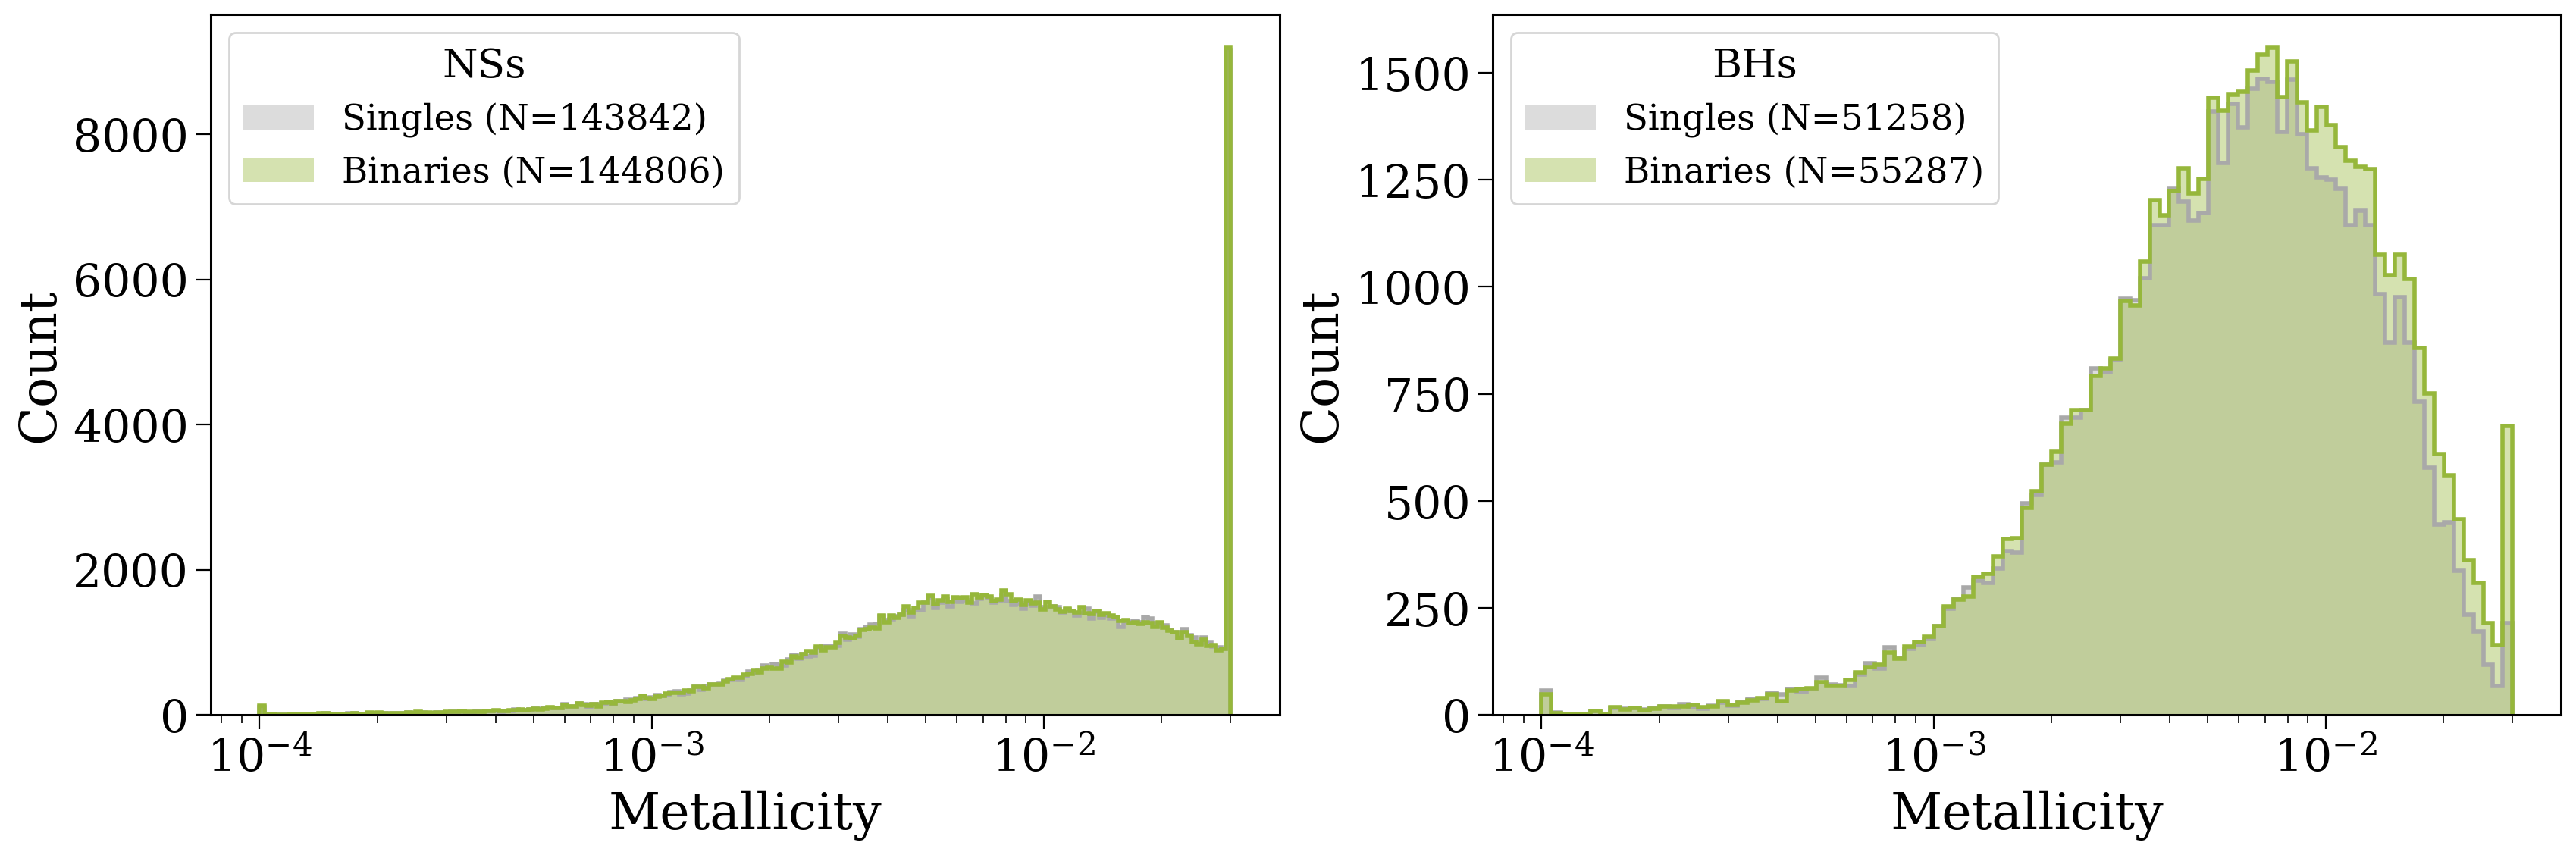

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.geomspace(1e-4, 0.03, 200), np.geomspace(1e-4, 0.03, 100)]):
    for pop in [singles, binaries]:
        init_Z = np.concatenate((
            pop.initC["metallicity"][pop.final_bpp["kstar_1"] == kstar],
            pop.initC["metallicity"][pop.final_bpp["kstar_2"] == kstar]
        ))

        ax.hist(init_Z, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(init_Z, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(init_Z)})")

    ax.set(
        xlabel=f"Metallicity",
        ylabel="Count",
        xscale='log'
    )
    ax.legend(title=f"{co_type}s")
plt.show()

## Delay time

Reproduces Wagg+25

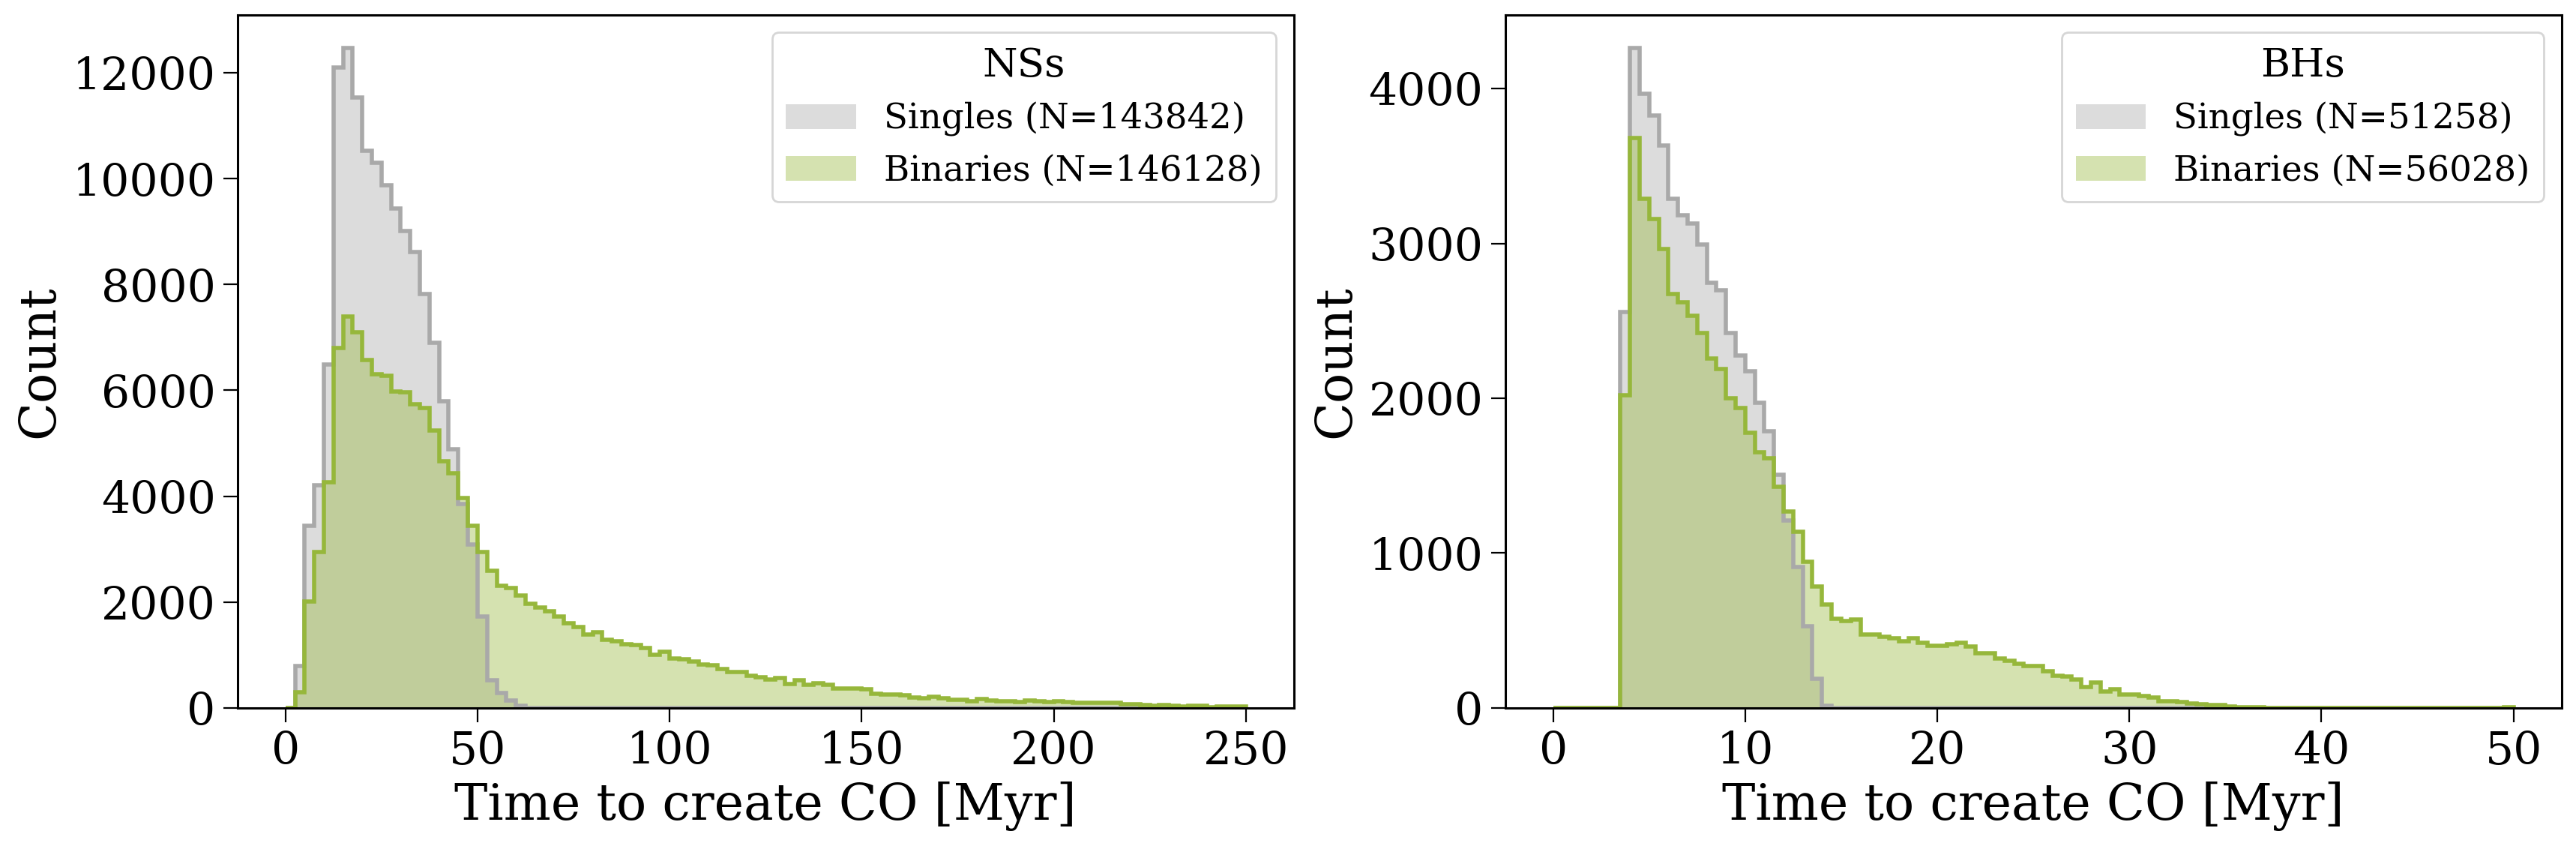

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 250, 101), np.linspace(0, 50, 101)]):
    for pop in [singles, binaries]:
        co_form_time = np.concatenate((
            pop.bpp[pop.bpp["kstar_1"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
            pop.bpp[pop.bpp["kstar_2"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
        ))

        ax.hist(co_form_time, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(co_form_time, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(co_form_time)})")

    ax.set(
        xlabel=f"Time to create CO [Myr]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s")
plt.show()